<a href="https://colab.research.google.com/github/deniaulainfead23/bioinformatica/blob/main/Pratica_Formul%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oficina de Pré-processamento de Dados
## Biomedicina e Farmácia

### Simulação: amostras laboratoriais didáticas

Os dados deste notebook são fictícios. Não representam pacientes, exames reais ou resultados clínicos.

**Objetivos:** identificar problemas, tratar dados ausentes, padronizar textos, validar números, detectar possíveis outliers, normalizar variáveis, discretizar dados e interpretar gráficos.

## Identificação dos grupos

Cada grupo deve ter pelo menos quatro estudantes. Preencham os nomes antes de começar.

### Grupo 1 - Diagnóstico
1. __________________________________  2. __________________________________
3. __________________________________  4. __________________________________

### Grupo 2 - Limpeza e padronização
1. __________________________________  2. __________________________________
3. __________________________________  4. __________________________________

### Grupo 3 - Dados numéricos
1. __________________________________  2. __________________________________
3. __________________________________  4. __________________________________

### Grupo 4 - Transformação e gráficos
1. __________________________________  2. __________________________________
3. __________________________________  4. __________________________________

**Sugestão de funções:** leitura da explicação, execução do código, observação do resultado e registro da conclusão.

## Organização da atividade

Cada grupo executará uma etapa e explicará à turma o que o código fez.

| Grupo | Etapa | Pergunta |
|---|---|---|
| 1 | Diagnóstico | Que problemas existem? |
| 2 | Limpeza | Como padronizar e tratar ausências? |
| 3 | Números | Como validar valores e detectar suspeitas? |
| 4 | Transformação | Como preparar e visualizar os dados? |

Uma decisão em uma etapa interfere nas seguintes. Por isso, todos devem acompanhar o notebook inteiro.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## Base bruta

Um laboratório didático reuniu informações de amostras para estudar a qualidade de uma preparação. Durante a coleta, foram inseridos problemas comuns em bases reais: ausências, grafias diferentes, texto em campo numérico, pH suspeito, temperatura discrepante e duplicidade. Olhe que foi criado um Dicionario

In [ ]:
dados = {
    'amostra_id': ['A01','A02','A03','A04','A05','A05','A06','A07','A08','A09','A10','A11'],
    'material': ['Sangue','urina ','Plasma','SANGUE','Urína','Urína','Saliva',None,'plasma','Sangue','SALIVA','Saliva'],
    'concentracao_mg_ml': ['2.5','1.8',None,'3,2','2.1','2.1','1.5','4.0','2.8','2.7','1.2','1.9'],
    'ph': [7.4,6.2,7.1,7.8,None,6.8,7.0,14.0,7.3,7.5,6.0,6.7],
    'temperatura_c': [36.8,37.1,36.5,38.0,36.9,36.9,37.2,36.7,80.0,36.6,37.0,None],
    'origem': ['Nova Iguaçu','nova iguaçu','Rio de Janeiro','RIO DE JANEIRO','Niterói','Niterói','nova iguaçu','Duque de Caxias','Rio de Janeiro','Niterói','duque de caxias','Nova Iguaçu'],
    'resultado': ['Adequado','adequado','Inadequado','ADEQUADO','Adequado','Adequado',None,'Inadequado','Adequado','adequado','Inadequado','Adequado']
}
df = pd.DataFrame(dados)
display(df)

### Carregando os Dados Reais do Formulário

Para trabalharmos com as respostas reais coletadas no arquivo Excel `/content/Respostas - Pré-processamento Biomedicina e Farmácia.xlsx`, vamos ler a planilha utilizando o `pandas`.

In [1]:
import pandas as pd

# Caminho do arquivo selecionado
caminho_arquivo = '/content/Respostas - Pré-processamento Biomedicina e Farmácia.xlsx'

# Carrega a planilha Excel
df_real = pd.read_excel(caminho_arquivo)

# Exibe as colunas presentes e as primeiras linhas para entendermos a estrutura real
print("Colunas encontradas no arquivo real:")
print(df_real.columns.tolist())

display(df_real.head())

Colunas encontradas no arquivo real:
['Timestamp', 'Nome do grupo ou código da equipe', 'Código da amostra', 'Qual é o material da amostra?', 'Qual é a concentração da amostra?', 'Qual é o pH observado?', 'Qual é a temperatura da amostra?', 'Qual é a cidade de origem da amostra didática?', 'Qual foi o resultado didático da análise?', 'Que problema de qualidade você imagina que pode aparecer nessa base?']


,Timestamp,Nome do grupo ou código da equipe,Código da amostra,Qual é o material da amostra?,Qual é a concentração da amostra?,Qual é o pH observado?,Qual é a temperatura da amostra?,Qual é a cidade de origem da amostra didática?,Qual foi o resultado didático da análise?,Que problema de qualidade você imagina que pode aparecer nessa base?
0,2026-09-30 19:57:14.169,Grupo1,A01,sangue,2,"6,8",38,Nova Iguaçu,inadequado,"ausência, duplicidade, grafia diferente, unid..."
1,2026-09-30 20:25:45.998,Grupo rosa,A02,Plasma,"2,5","6,8","37,1",Nova Iguaçu,Adequado,Duplicidade
2,2026-09-30 20:27:12.701,Liliane e Luma,U01,Urina,2.5,"5,5",27,Nova Iguaçu,Adequado,Nenhuna
3,2026-09-30 20:27:41.423,Grupo rosa,A07,Sangue,"2,5mg",7.2,37.1,Nova Iguaçu,Adequado,Ausência de dados
4,2026-09-30 20:27:41.497,Grupo rosa,A08,Urina,2.5,"6,8","36,8",Nova Iguaçu,Adequada,Ausência de dados


### Aplicando a Padronização nos Dados Reais

Após verificar as colunas do seu arquivo no passo anterior, você pode mapear e aplicar o mesmo pipeline de limpeza desenvolvido na oficina. Abaixo, temos um exemplo de estrutura genérica que você pode adaptar de acordo com as colunas reais importadas:

In [4]:
import unicodedata
import pandas as pd

# Função para remover acentos (definida aqui para evitar erro de NameError)
def remover_acentos(texto):
    if pd.isna(texto):
        return texto
    texto = unicodedata.normalize('NFKD', str(texto))
    return ''.join(c for c in texto if not unicodedata.combining(c))

# 1. Criar uma cópia dos dados reais para preservar o original
df_real_limpo = df_real.copy()

# 2. Renomear colunas para facilitar a manipulação
mapeamento_colunas = {
    'Nome do grupo ou código da equipe': 'grupo',
    'Código da amostra': 'amostra_id',
    'Qual é o material da amostra?': 'material',
    'Qual é a concentração da amostra?': 'concentracao_mg_ml',
    'Qual é o pH observado?': 'ph',
    'Qual é a temperatura da amostra?': 'temperatura_c',
    'Qual é a cidade de origem da amostra didática?': 'origem',
    'Qual foi o resultado didático da análise?': 'resultado'
}
df_real_limpo = df_real_limpo.rename(columns=mapeamento_colunas)

# 3. Limpar e padronizar colunas de texto (Material, Origem e Resultado)
colunas_categoricas = ['material', 'origem', 'resultado']
for col in colunas_categoricas:
    if col in df_real_limpo.columns:
        # Remove acentos, padroniza para maiúsculas e remove espaços nas pontas
        df_real_limpo[col] = df_real_limpo[col].apply(remover_acentos)
        df_real_limpo[col] = df_real_limpo[col].astype('string').str.strip().str.upper()

# Ajustar variações específicas de gênero (ex: ADEQUADA -> ADEQUADO)
if 'resultado' in df_real_limpo.columns:
    df_real_limpo['resultado'] = df_real_limpo['resultado'].replace({'ADEQUADA': 'ADEQUADO'})

# 4. Tratar e converter as colunas numéricas

# Tratamento da Concentração: remover 'mg' ou outras letras, trocar vírgula por ponto e converter para float
if 'concentracao_mg_ml' in df_real_limpo.columns:
    df_real_limpo['concentracao_mg_ml'] = (
        df_real_limpo['concentracao_mg_ml']
        .astype(str)
        .str.replace(r'[^0-9,\.]', '', regex=True) # Remove caracteres que não sejam números, ponto ou vírgula
        .str.replace(',', '.', regex=False)
    )
    df_real_limpo['concentracao_mg_ml'] = pd.to_numeric(df_real_limpo['concentracao_mg_ml'], errors='coerce')

# Tratamento do pH: trocar vírgula por ponto e converter para float
if 'ph' in df_real_limpo.columns:
    df_real_limpo['ph'] = df_real_limpo['ph'].astype(str).str.replace(',', '.', regex=False)
    df_real_limpo['ph'] = pd.to_numeric(df_real_limpo['ph'], errors='coerce')

# Tratamento da Temperatura: trocar vírgula por ponto e converter para float
if 'temperatura_c' in df_real_limpo.columns:
    df_real_limpo['temperatura_c'] = df_real_limpo['temperatura_c'].astype(str).str.replace(',', '.', regex=False)
    df_real_limpo['temperatura_c'] = pd.to_numeric(df_real_limpo['temperatura_c'], errors='coerce')

# 5. Visualizar o resultado final do pré-processamento dos dados reais
print("Dados reais após a padronização e limpeza:")
display(df_real_limpo[['amostra_id', 'material', 'concentracao_mg_ml', 'ph', 'temperatura_c', 'origem', 'resultado']].head(10))

Dados reais após a padronização e limpeza:


,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado
0,A01,SANGUE,2.0,6.80,38.0,NOVA IGUACU,INADEQUADO
1,A02,PLASMA,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO
2,U01,URINA,2.5,5.50,27.0,NOVA IGUACU,ADEQUADO
3,A07,SANGUE,2.5,7.20,37.1,NOVA IGUACU,ADEQUADO
4,A08,URINA,2.5,6.80,36.8,NOVA IGUACU,ADEQUADO
5,A11,SANGUE,5.2,6.80,36.8,NOVA IGUACU,INADEQUADO
6,F05,SANGUE,2.5,7.35,36.8,NOVA IGUACU,ADEQUADO
7,A02,URINA,2.5,5.80,36.8,NOVA IGUACU,ADEQUADO
8,A01,PLASMA,NaN,-0.18,15.0,RIO DE JANEIRO,ADEQUADO
9,A01,SANGUE,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO


## GRUPO 1 - Diagnóstico

Antes de corrigir, observe. O diagnóstico evita alterações sem justificativa.

In [7]:
print('Dimensões:', df_real_limpo.shape)
print('\nTipos de dados:')
display(df_real_limpo.dtypes.to_frame('tipo'))
print('\nAusências:')
display(df_real_limpo.isna().sum().to_frame('quantidade'))

Dimensões: (11, 10)

Tipos de dados:


,tipo
Timestamp,datetime64[ns]
grupo,object
amostra_id,object
material,string[python]
concentracao_mg_ml,float64
ph,float64
temperatura_c,float64
origem,string[python]
resultado,string[python]
Que problema de qualidade você imagina que pode aparecer nessa base?,object



Ausências:


,quantidade
Timestamp,0
grupo,0
amostra_id,0
material,0
concentracao_mg_ml,1
ph,0
temperatura_c,0
origem,0
resultado,0
Que problema de qualidade você imagina que pode aparecer nessa base?,2


In [ ]:
for coluna in ['material','origem','resultado']:
    print(f'\n{coluna}:', df[coluna].dropna().unique())

### Registro do Grupo 1

**Problemas encontrados:**

____________________________________________________________________

____________________________________________________________________

**Que dado deveria ser confirmado na fonte original?**

____________________________________________________________________

## GRUPO 2 - Limpeza e padronização

Informações equivalentes precisam ser reconhecidas como equivalentes. Vamos remover espaços, acentos e diferenças entre maiúsculas e minúsculas.

In [9]:
def remover_acentos(texto):
    if pd.isna(texto):
        return texto
    texto = unicodedata.normalize('NFKD', str(texto))
    return ''.join(c for c in texto if not unicodedata.combining(c))

for coluna in ['material','origem','resultado']:
    df_real_limpo[coluna] = df_real_limpo[coluna].apply(remover_acentos)
    df_real_limpo[coluna] = df_real_limpo[coluna].astype('string').str.strip().str.upper()

df_real_limpo['concentracao_mg_ml'] = df_real_limpo['concentracao_mg_ml'].astype('string').str.replace(',', '.', regex=False)
df_real_limpo['concentracao_mg_ml'] = pd.to_numeric(df_real_limpo['concentracao_mg_ml'], errors='coerce')

display(df_real_limpo)

,Timestamp,grupo,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado,Que problema de qualidade você imagina que pode aparecer nessa base?
0,2026-09-30 19:57:14.169,Grupo1,A01,SANGUE,2.0,6.80,38.0,NOVA IGUACU,INADEQUADO,"ausência, duplicidade, grafia diferente, unid..."
1,2026-09-30 20:25:45.998,Grupo rosa,A02,PLASMA,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO,Duplicidade
2,2026-09-30 20:27:12.701,Liliane e Luma,U01,URINA,2.5,5.50,27.0,NOVA IGUACU,ADEQUADO,Nenhuna
3,2026-09-30 20:27:41.423,Grupo rosa,A07,SANGUE,2.5,7.20,37.1,NOVA IGUACU,ADEQUADO,Ausência de dados
4,2026-09-30 20:27:41.497,Grupo rosa,A08,URINA,2.5,6.80,36.8,NOVA IGUACU,ADEQUADO,Ausência de dados
5,2026-09-30 20:27:45.518,Carla e Rayssa,A11,SANGUE,5.2,6.80,36.8,NOVA IGUACU,INADEQUADO,Valor fora do esperado
6,2026-09-30 20:28:33.776,Farma-05,F05,SANGUE,2.5,7.35,36.8,NOVA IGUACU,ADEQUADO,NaN
7,2026-09-30 20:31:30.081,Grupo Rosa,A02,URINA,2.5,5.80,36.8,NOVA IGUACU,ADEQUADO,NaN
8,2026-09-30 20:40:30.405,Elaine Ferreira,A01,PLASMA,<NA>,-0.18,15.0,RIO DE JANEIRO,ADEQUADO,Ausencia
9,2026-09-30 20:46:13.679,Winx1,A01,SANGUE,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO,Duplicidade


In [13]:
df_real_limpo['ph'] = df_real_limpo['ph'].fillna(df_real_limpo['ph'].median())
df_real_limpo['temperatura_c'] = df_real_limpo['temperatura_c'].fillna(df_real_limpo['temperatura_c'].median())
df_real_limpo['material'] = df_real_limpo['material'].fillna('NAO INFORMADO')
df_real_limpo['concentracao_mg_ml'] = df_real_limpo['concentracao_mg_ml'].fillna(df_real_limpo['concentracao_mg_ml'].median())
df_real_limpo['resultado'] = df_real_limpo['resultado'].fillna('NAO INFORMADO')

print('Ausências depois do tratamento:')
display(df_real_limpo.isna().sum().to_frame('quantidade'))

Ausências depois do tratamento:


,quantidade
Timestamp,0
grupo,0
amostra_id,0
material,0
concentracao_mg_ml,0
ph,0
temperatura_c,0
origem,0
resultado,0
Que problema de qualidade você imagina que pode aparecer nessa base?,2


### Registro do Grupo 2

**Por que não devemos preencher todo valor ausente com zero?**

____________________________________________________________________

**Qual foi a vantagem da padronização?**

____________________________________________________________________

## GRUPO 3 - Validação numérica e possíveis outliers

Um valor discrepante não é automaticamente um erro. Ele pode ser uma situação real, um erro de digitação ou um problema de medição. Primeiro sinalizamos; depois investigamos.

In [14]:
print('pH fora do intervalo didático:')
display(df_real_limpo[~df_real_limpo['ph'].between(0, 10)])

print('Temperatura suspeita:')
display(df_real_limpo[~df_real_limpo['temperatura_c'].between(30, 45)])

print('Possíveis duplicidades:')
display(df_real_limpo[df_real_limpo.duplicated('amostra_id', keep=False)])

pH fora do intervalo didático:


,Timestamp,grupo,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado,Que problema de qualidade você imagina que pode aparecer nessa base?
8,2026-09-30 20:40:30.405,Elaine Ferreira,A01,PLASMA,2.5,-0.18,15.0,RIO DE JANEIRO,ADEQUADO,Ausencia


Temperatura suspeita:


,Timestamp,grupo,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado,Que problema de qualidade você imagina que pode aparecer nessa base?
2,2026-09-30 20:27:12.701,Liliane e Luma,U01,URINA,2.5,5.50,27.0,NOVA IGUACU,ADEQUADO,Nenhuna
8,2026-09-30 20:40:30.405,Elaine Ferreira,A01,PLASMA,2.5,-0.18,15.0,RIO DE JANEIRO,ADEQUADO,Ausencia


Possíveis duplicidades:


,Timestamp,grupo,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado,Que problema de qualidade você imagina que pode aparecer nessa base?
0,2026-09-30 19:57:14.169,Grupo1,A01,SANGUE,2.0,6.80,38.0,NOVA IGUACU,INADEQUADO,"ausência, duplicidade, grafia diferente, unid..."
1,2026-09-30 20:25:45.998,Grupo rosa,A02,PLASMA,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO,Duplicidade
7,2026-09-30 20:31:30.081,Grupo Rosa,A02,URINA,2.5,5.80,36.8,NOVA IGUACU,ADEQUADO,NaN
8,2026-09-30 20:40:30.405,Elaine Ferreira,A01,PLASMA,2.5,-0.18,15.0,RIO DE JANEIRO,ADEQUADO,Ausencia
9,2026-09-30 20:46:13.679,Winx1,A01,SANGUE,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO,Duplicidade


In [17]:
# Decisão didática: confirmar, corrigir ou marcar para investigação.
ph_validos = df_real_limpo.loc[df_real_limpo['ph'].between(0, 10), 'ph']
df_real_limpo.loc[~df_real_limpo['ph'].between(0, 10), 'ph'] = ph_validos.median()

df_real_limpo.loc[~df_real_limpo['temperatura_c'].between(30, 45), 'temperatura_c'] = None
df_real_limpo['temperatura_c'] = df_real_limpo['temperatura_c'].fillna(df_real_limpo['temperatura_c'].median())

df_real_limpo = df_real_limpo.drop_duplicates(subset='amostra_id', keep='first').reset_index(drop=True)
display(df_real_limpo)

,Timestamp,grupo,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado,Que problema de qualidade você imagina que pode aparecer nessa base?
0,2026-09-30 19:57:14.169,Grupo1,A01,SANGUE,2.0,6.80,38.0,NOVA IGUACU,INADEQUADO,"ausência, duplicidade, grafia diferente, unid..."
1,2026-09-30 20:25:45.998,Grupo rosa,A02,PLASMA,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO,Duplicidade
2,2026-09-30 20:27:12.701,Liliane e Luma,U01,URINA,2.5,5.50,36.9,NOVA IGUACU,ADEQUADO,Nenhuna
3,2026-09-30 20:27:41.423,Grupo rosa,A07,SANGUE,2.5,7.20,37.1,NOVA IGUACU,ADEQUADO,Ausência de dados
4,2026-09-30 20:27:41.497,Grupo rosa,A08,URINA,2.5,6.80,36.8,NOVA IGUACU,ADEQUADO,Ausência de dados
5,2026-09-30 20:27:45.518,Carla e Rayssa,A11,SANGUE,5.2,6.80,36.8,NOVA IGUACU,INADEQUADO,Valor fora do esperado
6,2026-09-30 20:28:33.776,Farma-05,F05,SANGUE,2.5,7.35,36.8,NOVA IGUACU,ADEQUADO,NaN
7,2026-09-30 20:46:32.298,Equipe azul,A04,SALIVA,2.5,6.90,36.9,NOVA IGUACU,FOI POSTERIORMENTE NO PYTHON,Valor fora do esperando


### Registro do Grupo 3

**Por que um outlier não deve ser apagado automaticamente?**

____________________________________________________________________

**Que documento ou pessoa poderia confirmar uma medição suspeita?**

____________________________________________________________________

## GRUPO 4 - Normalização e discretização

A normalização coloca uma variável em outra escala. A discretização transforma números em categorias.

In [19]:
df_real_limpo['concentracao_normalizada'] = (
    (df_real_limpo['concentracao_mg_ml'] - df_real_limpo['concentracao_mg_ml'].min()) /
    (df_real_limpo['concentracao_mg_ml'].max() - df_real_limpo['concentracao_mg_ml'].min())
)

def classificar_ph(valor):
    if valor < 6.5:
        return 'ACIDO'
    elif valor <= 7.5:
        return 'PROXIMO_DA_NEUTRALIDADE'
    return 'ALCALINO'

df_real_limpo['categoria_ph'] = df_real_limpo['ph'].apply(classificar_ph)
display(df_real_limpo[['amostra_id','concentracao_mg_ml','concentracao_normalizada','ph','categoria_ph']])

,amostra_id,concentracao_mg_ml,concentracao_normalizada,ph,categoria_ph
0,A01,2.0,0.0,6.80,PROXIMO_DA_NEUTRALIDADE
1,A02,2.5,0.15625,6.80,PROXIMO_DA_NEUTRALIDADE
2,U01,2.5,0.15625,5.50,ACIDO
3,A07,2.5,0.15625,7.20,PROXIMO_DA_NEUTRALIDADE
4,A08,2.5,0.15625,6.80,PROXIMO_DA_NEUTRALIDADE
5,A11,5.2,1.0,6.80,PROXIMO_DA_NEUTRALIDADE
6,F05,2.5,0.15625,7.35,PROXIMO_DA_NEUTRALIDADE
7,A04,2.5,0.15625,6.90,PROXIMO_DA_NEUTRALIDADE


### Gráfico de barras

Usamos barras para comparar categorias, como a quantidade de cada tipo de material.

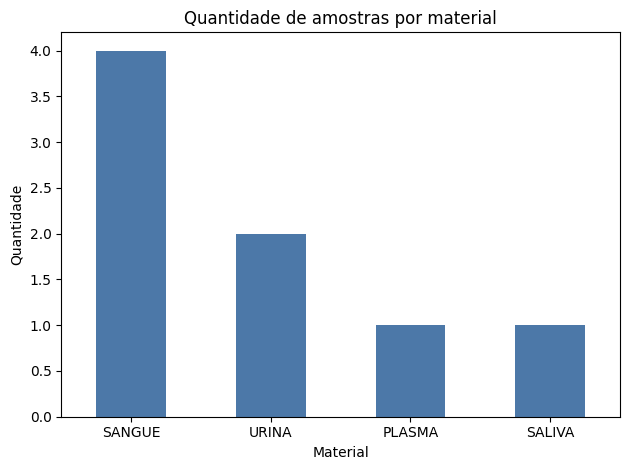

In [25]:
import matplotlib.pyplot as plt

df_real_limpo['material'].value_counts().plot(kind='bar', color='#4C78A8')
plt.title('Quantidade de amostras por material')
plt.xlabel('Material')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Boxplot

O boxplot permite observar a distribuição dos valores e possíveis valores discrepantes.

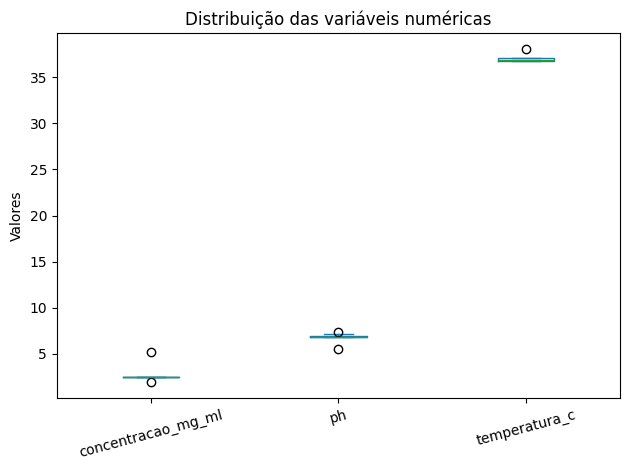

In [26]:
df_real_limpo[['concentracao_mg_ml','ph','temperatura_c']].plot(kind='box')
plt.title('Distribuição das variáveis numéricas')
plt.ylabel('Valores')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Gráfico de dispersão

O gráfico de dispersão compara duas variáveis numéricas. Uma relação visual não prova causa e efeito.

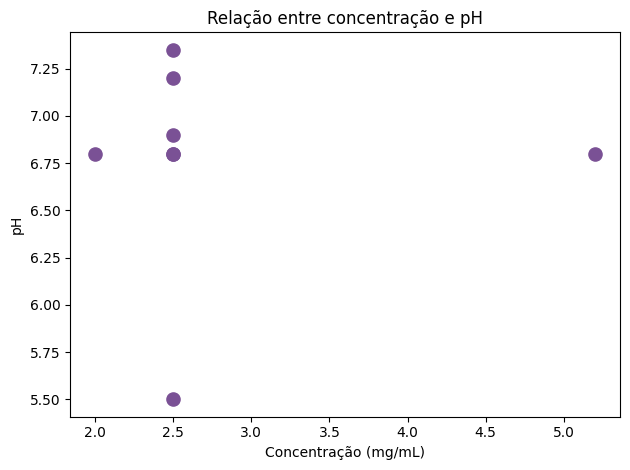

In [27]:
df_real_limpo.plot(x='concentracao_mg_ml', y='ph', kind='scatter', color='#7A5195', s=90)
plt.title('Relação entre concentração e pH')
plt.xlabel('Concentração (mg/mL)')
plt.ylabel('pH')
plt.tight_layout()
plt.show()

## Conferência final

Pré-processar não é esconder problemas. É identificar, documentar e tratar os dados com justificativa.

In [28]:
print('Formato final:', df_real_limpo.shape)
print('Ausências restantes:')
display(df_real_limpo.isna().sum().to_frame('quantidade'))
display(df_real_limpo)

Formato final: (8, 12)
Ausências restantes:


,quantidade
Timestamp,0
grupo,0
amostra_id,0
material,0
concentracao_mg_ml,0
ph,0
temperatura_c,0
origem,0
resultado,0
Que problema de qualidade você imagina que pode aparecer nessa base?,1


,Timestamp,grupo,amostra_id,material,concentracao_mg_ml,ph,temperatura_c,origem,resultado,Que problema de qualidade você imagina que pode aparecer nessa base?,concentracao_normalizada,categoria_ph
0,2026-09-30 19:57:14.169,Grupo1,A01,SANGUE,2.0,6.80,38.0,NOVA IGUACU,INADEQUADO,"ausência, duplicidade, grafia diferente, unid...",0.0,PROXIMO_DA_NEUTRALIDADE
1,2026-09-30 20:25:45.998,Grupo rosa,A02,PLASMA,2.5,6.80,37.1,NOVA IGUACU,ADEQUADO,Duplicidade,0.15625,PROXIMO_DA_NEUTRALIDADE
2,2026-09-30 20:27:12.701,Liliane e Luma,U01,URINA,2.5,5.50,36.9,NOVA IGUACU,ADEQUADO,Nenhuna,0.15625,ACIDO
3,2026-09-30 20:27:41.423,Grupo rosa,A07,SANGUE,2.5,7.20,37.1,NOVA IGUACU,ADEQUADO,Ausência de dados,0.15625,PROXIMO_DA_NEUTRALIDADE
4,2026-09-30 20:27:41.497,Grupo rosa,A08,URINA,2.5,6.80,36.8,NOVA IGUACU,ADEQUADO,Ausência de dados,0.15625,PROXIMO_DA_NEUTRALIDADE
5,2026-09-30 20:27:45.518,Carla e Rayssa,A11,SANGUE,5.2,6.80,36.8,NOVA IGUACU,INADEQUADO,Valor fora do esperado,1.0,PROXIMO_DA_NEUTRALIDADE
6,2026-09-30 20:28:33.776,Farma-05,F05,SANGUE,2.5,7.35,36.8,NOVA IGUACU,ADEQUADO,NaN,0.15625,PROXIMO_DA_NEUTRALIDADE
7,2026-09-30 20:46:32.298,Equipe azul,A04,SALIVA,2.5,6.90,36.9,NOVA IGUACU,FOI POSTERIORMENTE NO PYTHON,Valor fora do esperando,0.15625,PROXIMO_DA_NEUTRALIDADE


## Conclusão individual

1. Diferencie dado ausente, inconsistente e ruído.
2. Por que a concentração precisou ser convertida para número?
3. Qual técnica criou a categoria do pH?
4. Qual gráfico foi mais útil para comparar materiais?
5. Que decisão deveria ser confirmada em um laboratório real?
6. Por que uma base mal preparada prejudica análises e modelos de inteligência artificial?

**Frase do grupo:**

Uma base de dados de qualidade é importante porque ________________________________________________.

## Conceitos revisados

| Técnica | Aplicação |
|---|---|
| Inspeção | observar linhas, colunas e tipos |
| Limpeza | tratar ausências e duplicidades |
| Padronização | uniformizar textos |
| Conversão | transformar texto numérico em número |
| Validação | sinalizar valores suspeitos |
| Normalização | transformar concentração para 0 a 1 |
| Discretização | transformar pH em categorias |
| Visualização | barras, boxplot e dispersão |